In [2]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [21]:
def eval_metric(random_dir, extra_param=None):

    norm_dists = []
    mismatches = []
    likelihoods = []
    snrs = []
    extra_params = []
    inj_dirs = os.path.join(random_dir, 'injections')
    for inj_dir in os.listdir(inj_dirs):
        inj_dir = os.path.join(inj_dirs, inj_dir, 'outdir', 'output')

        # Load in metric and injected parameters
        try:
            filepath = os.path.join(inj_dir, 'analysis_metric.pkl')
            with open(filepath, 'rb') as f:
                metric = pickle.load(f)
            filepath = os.path.join(inj_dir, 'converted_injection_parameters.json')
            with open(filepath, 'r') as f:
                all_inj_params = json.load(f)
            if 'ecc10sqrd' not in all_inj_params['posterior_samples'].keys():
                if 'ecc10' in all_inj_params['posterior_samples'].keys():
                    all_inj_params['posterior_samples']['ecc10sqrd'] = [all_inj_params['posterior_samples']['ecc10'][0]**2]
        except:
            continue

        if 'injection_36' in inj_dir:
            print(all_inj_params)

        # Calculate distance, mismatch, and likelihood between peak and injected in dx coordinates
        inj_params = np.zeros(len(metric.dxs))
        for i, dx in enumerate(metric.dxs):
            inj_params[i] = all_inj_params['posterior_samples'][dx][0]
            inj_params[i] -= metric.x[dx][0]
        inj_params_dx = np.matmul(np.linalg.inv(metric.normalized_evecs().samples), inj_params)
        norm_dists.append(np.sqrt(np.sum(inj_params_dx**2)))
        mismatches.append(metric.mismatch[0]*norm_dists[-1]**2)
        if mismatches[-1] > 0.025:
            print(norm_dists[-1], mismatches[-1], inj_dir)
        if mismatches[-1] > 1:
            mismatches[-1] = 1
        likelihoods.append(np.exp(-metric.snr[0]**2/2 * (1-(1-mismatches[-1])**2)))
        snrs.append(all_inj_params['posterior_samples']['network'][0])
        if extra_param:
            extra_params.append(all_inj_params['posterior_samples'][extra_param][0])

    if extra_param:
        return norm_dists, mismatches, likelihoods, snrs, extra_params
    else:
        return norm_dists, mismatches, likelihoods, snrs

1.5792081001050593 0.056657063681353446 /home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_14/outdir/output
8.1999138457325 0.6781371009386371 /home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_7/outdir/output
7.200928557539053 1.7983220019241004 /home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/injections/injection_48/outdir/output
{'posterior_samples': {'21': [2.8687419753789105], '22': [12.745539738048556], '32': [0.8315760854643116], '33': [4.192701687970648], '44': [2.2745485273738013], 'a_1': [0.2170248534391581], 'a_2': [0.3386403754366512], 'alpha_net': [0.37950068783327556], 'beta': [0.0], 'chi_align': [-0.11475221045818555], 'chi_eff': [-0.07999867740076166], 'chi_p': [0.0], 'chi_p_2spin': [0.0], 'chirp_mass': [26.208626348659113], 'chirp_mass_source': [23.55389460630421], 'comoving_distance': [485.522545431549], 'comoving_volume': [479420734.9550382], 'cos

Text(0, 0.5, 'Cumulative fraction')

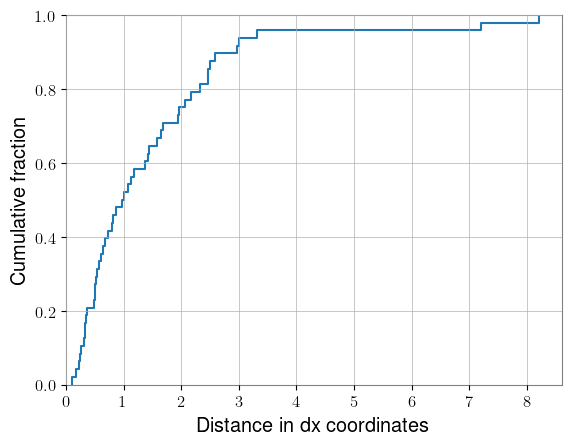

In [22]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
sorted_dists = np.sort([*norm_dists, np.max(norm_dists)+10**-9])
plt.step(sorted_dists, np.arange(len(sorted_dists))/len(norm_dists))
# random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v9/'
# norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
# sorted_dists = np.sort([*norm_dists, np.max(norm_dists)+10**-9])
# plt.step(sorted_dists, np.arange(len(sorted_dists))/len(norm_dists))
plt.xlim(0,)
plt.ylim(0, 1)
plt.xlabel('Distance in dx coordinates')
plt.ylabel('Cumulative fraction')

Text(0, 0.5, 'Cumulative fraction')

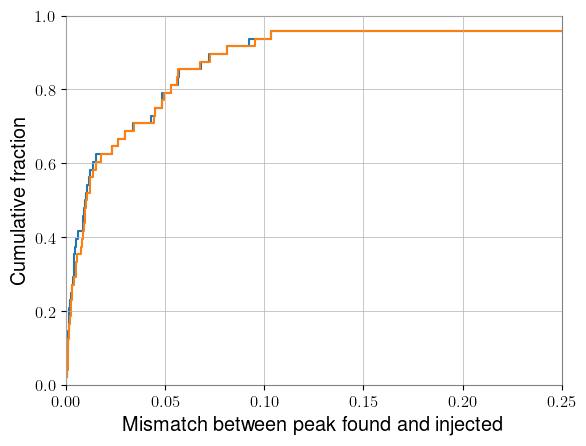

In [5]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
sorted_ms = np.sort([*mismatches, np.max(mismatches)+10**-9])
plt.step(sorted_ms, np.arange(len(sorted_ms))/len(mismatches))
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v9/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
sorted_ms = np.sort([*mismatches, np.max(mismatches)+10**-9])
plt.step(sorted_ms, np.arange(len(sorted_ms))/len(mismatches))
plt.xlim(0, 0.25)
plt.ylim(0, 1)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel('Cumulative fraction')

Text(0, 0.5, 'Cumulative fraction')

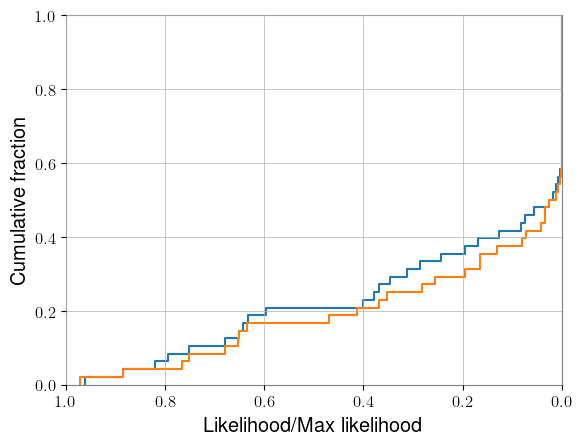

In [6]:
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
sorted_Ls = np.sort([*likelihoods, np.min(mismatches)-10**-9])[::-1]
plt.step(sorted_Ls, np.arange(len(sorted_Ls))/len(likelihoods))
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v9/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
sorted_Ls = np.sort([*likelihoods, np.min(mismatches)-10**-9])[::-1]
plt.step(sorted_Ls, np.arange(len(sorted_Ls))/len(likelihoods))
plt.xlim(1, 0)
plt.ylim(0, 1)
plt.xlabel('Likelihood/Max likelihood')
plt.ylabel('Cumulative fraction')

Text(0.5, 1.0, 'Pearson coefficient of -0.076')

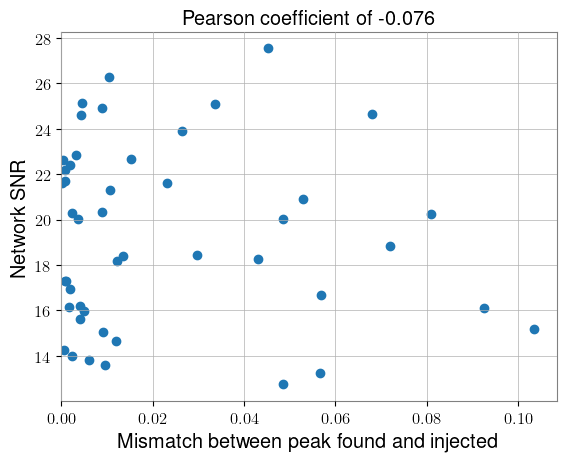

In [72]:
from scipy.stats import pearsonr
max_mm = 0.2
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs = eval_metric(random_dir)
mismatches = np.array(mismatches)
snrs = np.array(snrs)
adjust_mms = mismatches[mismatches<max_mm]
adjust_snrs = snrs[mismatches<max_mm]
presult = pearsonr(adjust_mms, adjust_snrs)
plt.scatter(adjust_mms, adjust_snrs)
plt.xlim(0, None)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel('Network SNR')
plt.title(f'Pearson coefficient of {presult.statistic:.3f}')

Text(0.5, 1.0, 'Pearson coefficient of 0.586')

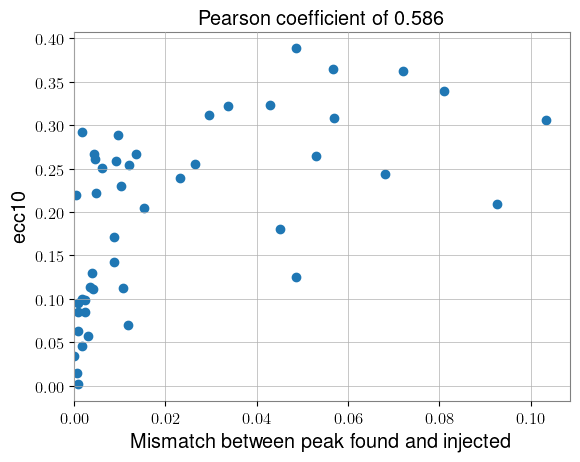

In [68]:
from scipy.stats import pearsonr
max_mm = 0.2
param = 'ecc10'
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs, extra = eval_metric(random_dir, extra_param=param)
mismatches = np.array(mismatches)
extra = np.array(extra)
adjust_mms = mismatches[mismatches<max_mm]
adjust_extras = extra[mismatches<max_mm]
presult = pearsonr(adjust_mms, adjust_extras)
plt.scatter(adjust_mms, adjust_extras)
plt.xlim(0, None)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel(param)
plt.title(f'Pearson coefficient of {presult.statistic:.3f}')

Text(0.5, 1.0, 'Pearson coefficient of 0.055')

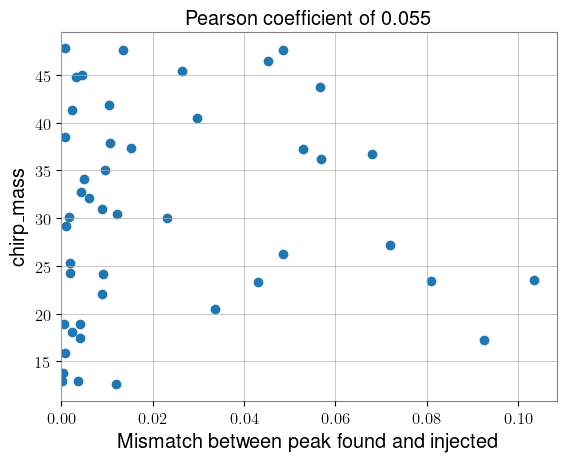

In [67]:
from scipy.stats import pearsonr
max_mm = 0.2
param = 'chirp_mass'
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs, extra = eval_metric(random_dir, extra_param=param)
mismatches = np.array(mismatches)
extra = np.array(extra)
adjust_mms = mismatches[mismatches<max_mm]
adjust_extras = extra[mismatches<max_mm]
presult = pearsonr(adjust_mms, adjust_extras)
plt.scatter(adjust_mms, adjust_extras)
plt.xlim(0, None)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel(param)
plt.title(f'Pearson coefficient of {presult.statistic:.3f}')

Text(0.5, 1.0, 'Pearson coefficient of -0.073')

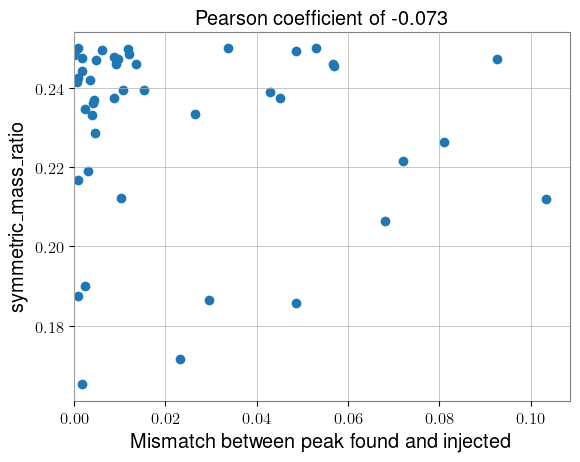

In [62]:
from scipy.stats import pearsonr
max_mm = 0.2
param = 'symmetric_mass_ratio'
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs, extra = eval_metric(random_dir, extra_param=param)
mismatches = np.array(mismatches)
extra = np.array(extra)
adjust_mms = mismatches[mismatches<max_mm]
adjust_extras = extra[mismatches<max_mm]
presult = pearsonr(adjust_mms, adjust_extras)
plt.scatter(adjust_mms, adjust_extras)
plt.xlim(0, None)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel(param)
plt.title(f'Pearson coefficient of {presult.statistic:.3f}')

Text(0.5, 1.0, 'Pearson coefficient of 0.010')

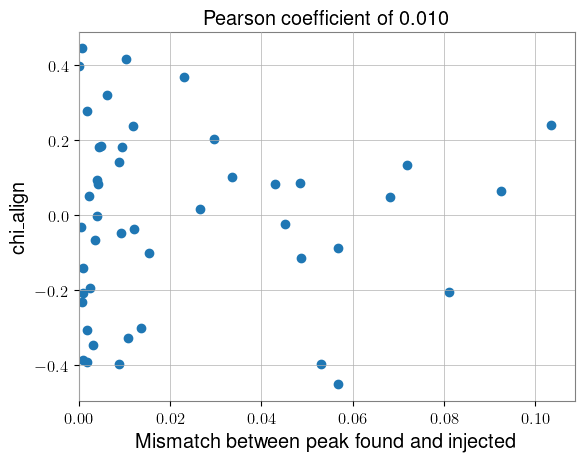

In [63]:
from scipy.stats import pearsonr
max_mm = 0.2
param = 'chi_align'
random_dir = '/home/ben.patterson/projects/ecc_simple_pe_runs/random_sets/zero_noise_50_v3/'
norm_dists, mismatches, likelihoods, snrs, extra = eval_metric(random_dir, extra_param=param)
mismatches = np.array(mismatches)
extra = np.array(extra)
adjust_mms = mismatches[mismatches<max_mm]
adjust_extras = extra[mismatches<max_mm]
presult = pearsonr(adjust_mms, adjust_extras)
plt.scatter(adjust_mms, adjust_extras)
plt.xlim(0, None)
plt.xlabel('Mismatch between peak found and injected')
plt.ylabel(param)
plt.title(f'Pearson coefficient of {presult.statistic:.3f}')

In [42]:
presult.pvalue

0.6164314121526431